# Problem definition

Telecom companies lose significant revenue when customers cancel their subscriptions, a problem known as churn. 
Using a dataset of 7,043 telecom customers, we build a binary classification model to predict whether a customer is likely to churn based on their demographics, subscription type, contract details and usage patterns. This helps the telecom business proactively identify at-risk customers and intervene before they leave reducing revenue loss and improving customer retention.

### Data Dictionary:

1. CustomerID: A unique identifier assigned to each telecom customer, enabling tracking and
identification of individual customers.

3. Gender: The gender of the customer, which can be categorized as male, or female. This
information helps in analyzing gender-based trends in customer churn.


5. SeniorCitizen: A binary indicator that identifies whether the customer is a senior citizen or not.
This attribute helps in understanding if there are any specific churn patterns among senior
customers.


7. Partner: Indicates whether the customer has a partner or not. This attribute helps in
evaluating the impact of having a partner on churn behavior.


9. Dependents: Indicates whether the customer has dependents or not. This attribute helps in
assessing the influence of having dependents on customer churn.


11. Tenure: The duration for which the customer has been subscribed to the telecom service. It
represents the loyalty or longevity of the customer’s relationship with the company and is a
significant predictor of churn.


13. PhoneService: Indicates whether the customer has a phone service or not. This attribute
helps in understanding the impact of phone service on churn.


15. MultipleLines: Indicates whether the customer has multiple lines or not. This attribute helps in
analyzing the effect of having multiple lines on customer churn.


17. InternetService: Indicates the type of internet service subscribed by the customer, such as
DSL, fiber optic, or no internet service. It helps in evaluating the relationship between internet
service and churn.


19. OnlineSecurity: Indicates whether the customer has online security services or not. This
attribute helps in analyzing the impact of online security on customer churn.


21. OnlineBackup: Indicates whether the customer has online backup services or not. This
attribute helps in evaluating the impact of online backup on churn behavior.


23. DeviceProtection: Indicates whether the customer has device protection services or not.
This attribute helps in understanding the influence of device protection on churn.


25. TechSupport: Indicates whether the customer has technical support services or not. This
attribute helps in assessing the impact of tech support on churn behavior.


27. StreamingTV: Indicates whether the customer has streaming TV services or not. This
attribute helps in evaluating the impact of streaming TV on customer churn.


29. StreamingMovies: Indicates whether the customer has streaming movie services or not. This
attribute helps in understanding the influence of streaming movies on churn behavior.


31. Contract: Indicates the type of contract the customer has, such as a month-to-month,
one-year, or two-year contract. It is a crucial factor in predicting churn as different contract
lengths may have varying impacts on customer loyalty.


33. PaperlessBilling: Indicates whether the customer has opted for paperless billing or not. This
attribute helps in analyzing the effect of paperless billing on customer churn.


35. PaymentMethod: Indicates the method of payment used by the customer, such as electronic
checks, mailed checks, bank transfers, or credit cards. This attribute helps in evaluating the
impact of payment methods on churn.


37. MonthlyCharges: The amount charged to the customer on a monthly basis. It helps in
understanding the relationship between monthly charges and churn behavior.


39. TotalCharges: The total amount charged to the customer over the entire tenure. It
represents the cumulative revenue generated from the customer and may have an impact on
churn.


41. Churn: The target variable indicates whether the customer has churned (canceled the
service) or not. It is the main variable to predict in telecom customer churn analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv("Customer-Churn (1) 2.csv")
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce") 
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')

In [8]:
df.describe(include="object")

,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,5901,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [9]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [10]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
(df["TotalCharges"].isna() & (df["tenure"] == 0)).sum()

11

Missing values in TotalCharges occur only when tenure = 0.
These represent customers who have not yet been billed.
Rather than dropping or statistically imputing, the values were set to 0 to preserve business logic.

In [13]:
df.loc[df["tenure"] == 0, "TotalCharges"] = 0

In [14]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df.duplicated().sum()

0

## univariate analysis

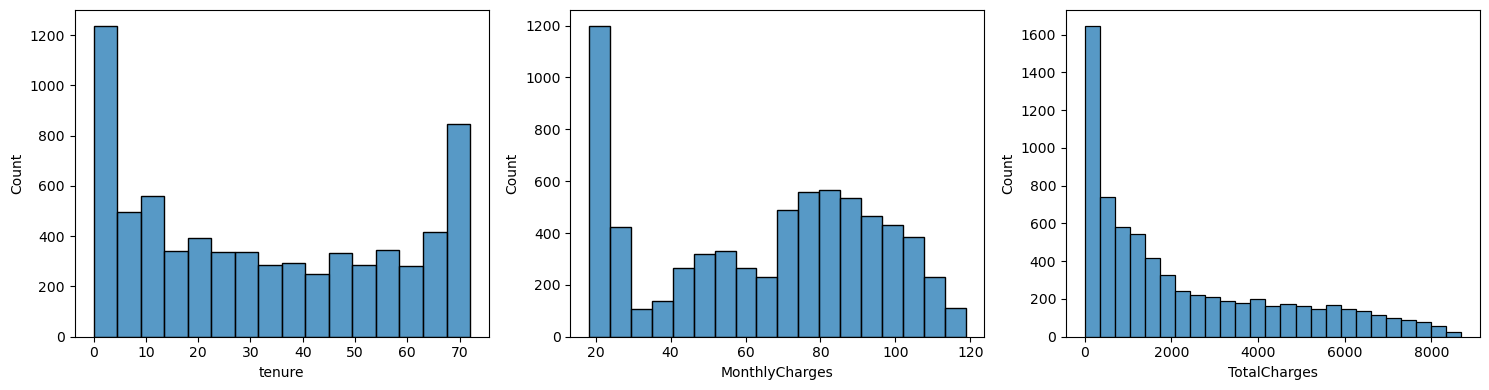

In [17]:
num_features = df.select_dtypes(include=['number']).columns.tolist()
import math
n= len(num_features)
rows = math.ceil(n/3)
plt.figure(figsize=(15, rows * 4))

for i, feature in enumerate(num_features):
    plt.subplot(rows, 3, i+1)    
    sns.histplot(data=df, x=feature)    

plt.tight_layout();   

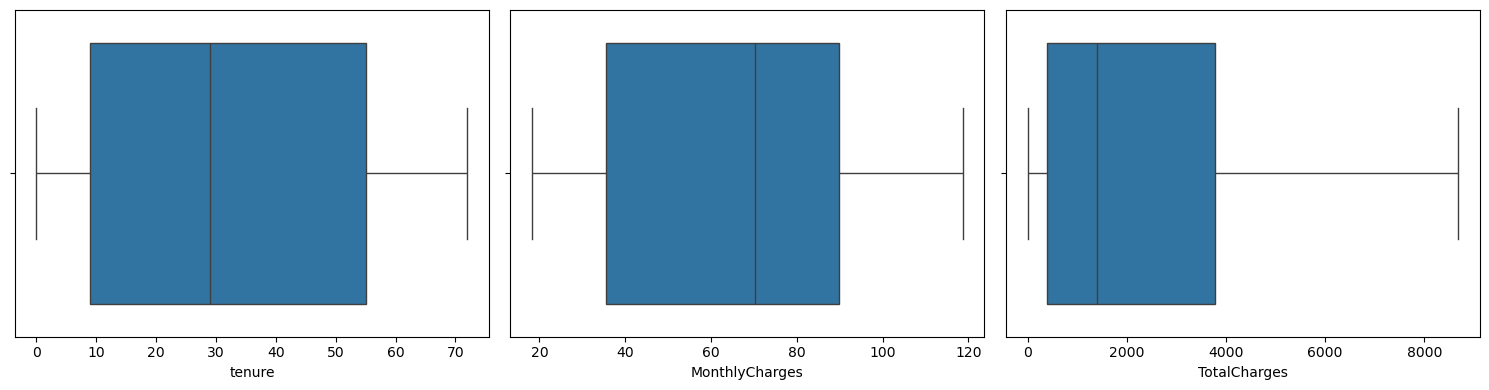

In [18]:
num_features = df.select_dtypes(include=['number']).columns.tolist()
import math
n= len(num_features)
rows = math.ceil(n/3)
plt.figure(figsize=(15, rows * 4))

for i, feature in enumerate(num_features):
    plt.subplot(rows, 3, i+1)    
    sns.boxplot(data=df, x=feature)    
plt.tight_layout();   




- `tenure` is fairly uniformly distributed, with 50% of customers 
  subscribed between 10 and 55 months suggesting a mix of new 
  and long standing customers in the dataset.
- `MonthlyCharges` shows high variability ranging from 18 to 118, 
  indicating the telecom offers a wide range of pricing plans.
- `TotalCharges` is right skewed as expected it's directly 
  influenced by tenure, so newer customers naturally have lower 
  cumulative charges.
- No significant outliers were detected in numerical features, 
  so no removal was necessary.

### univariate analysis for categorical variables

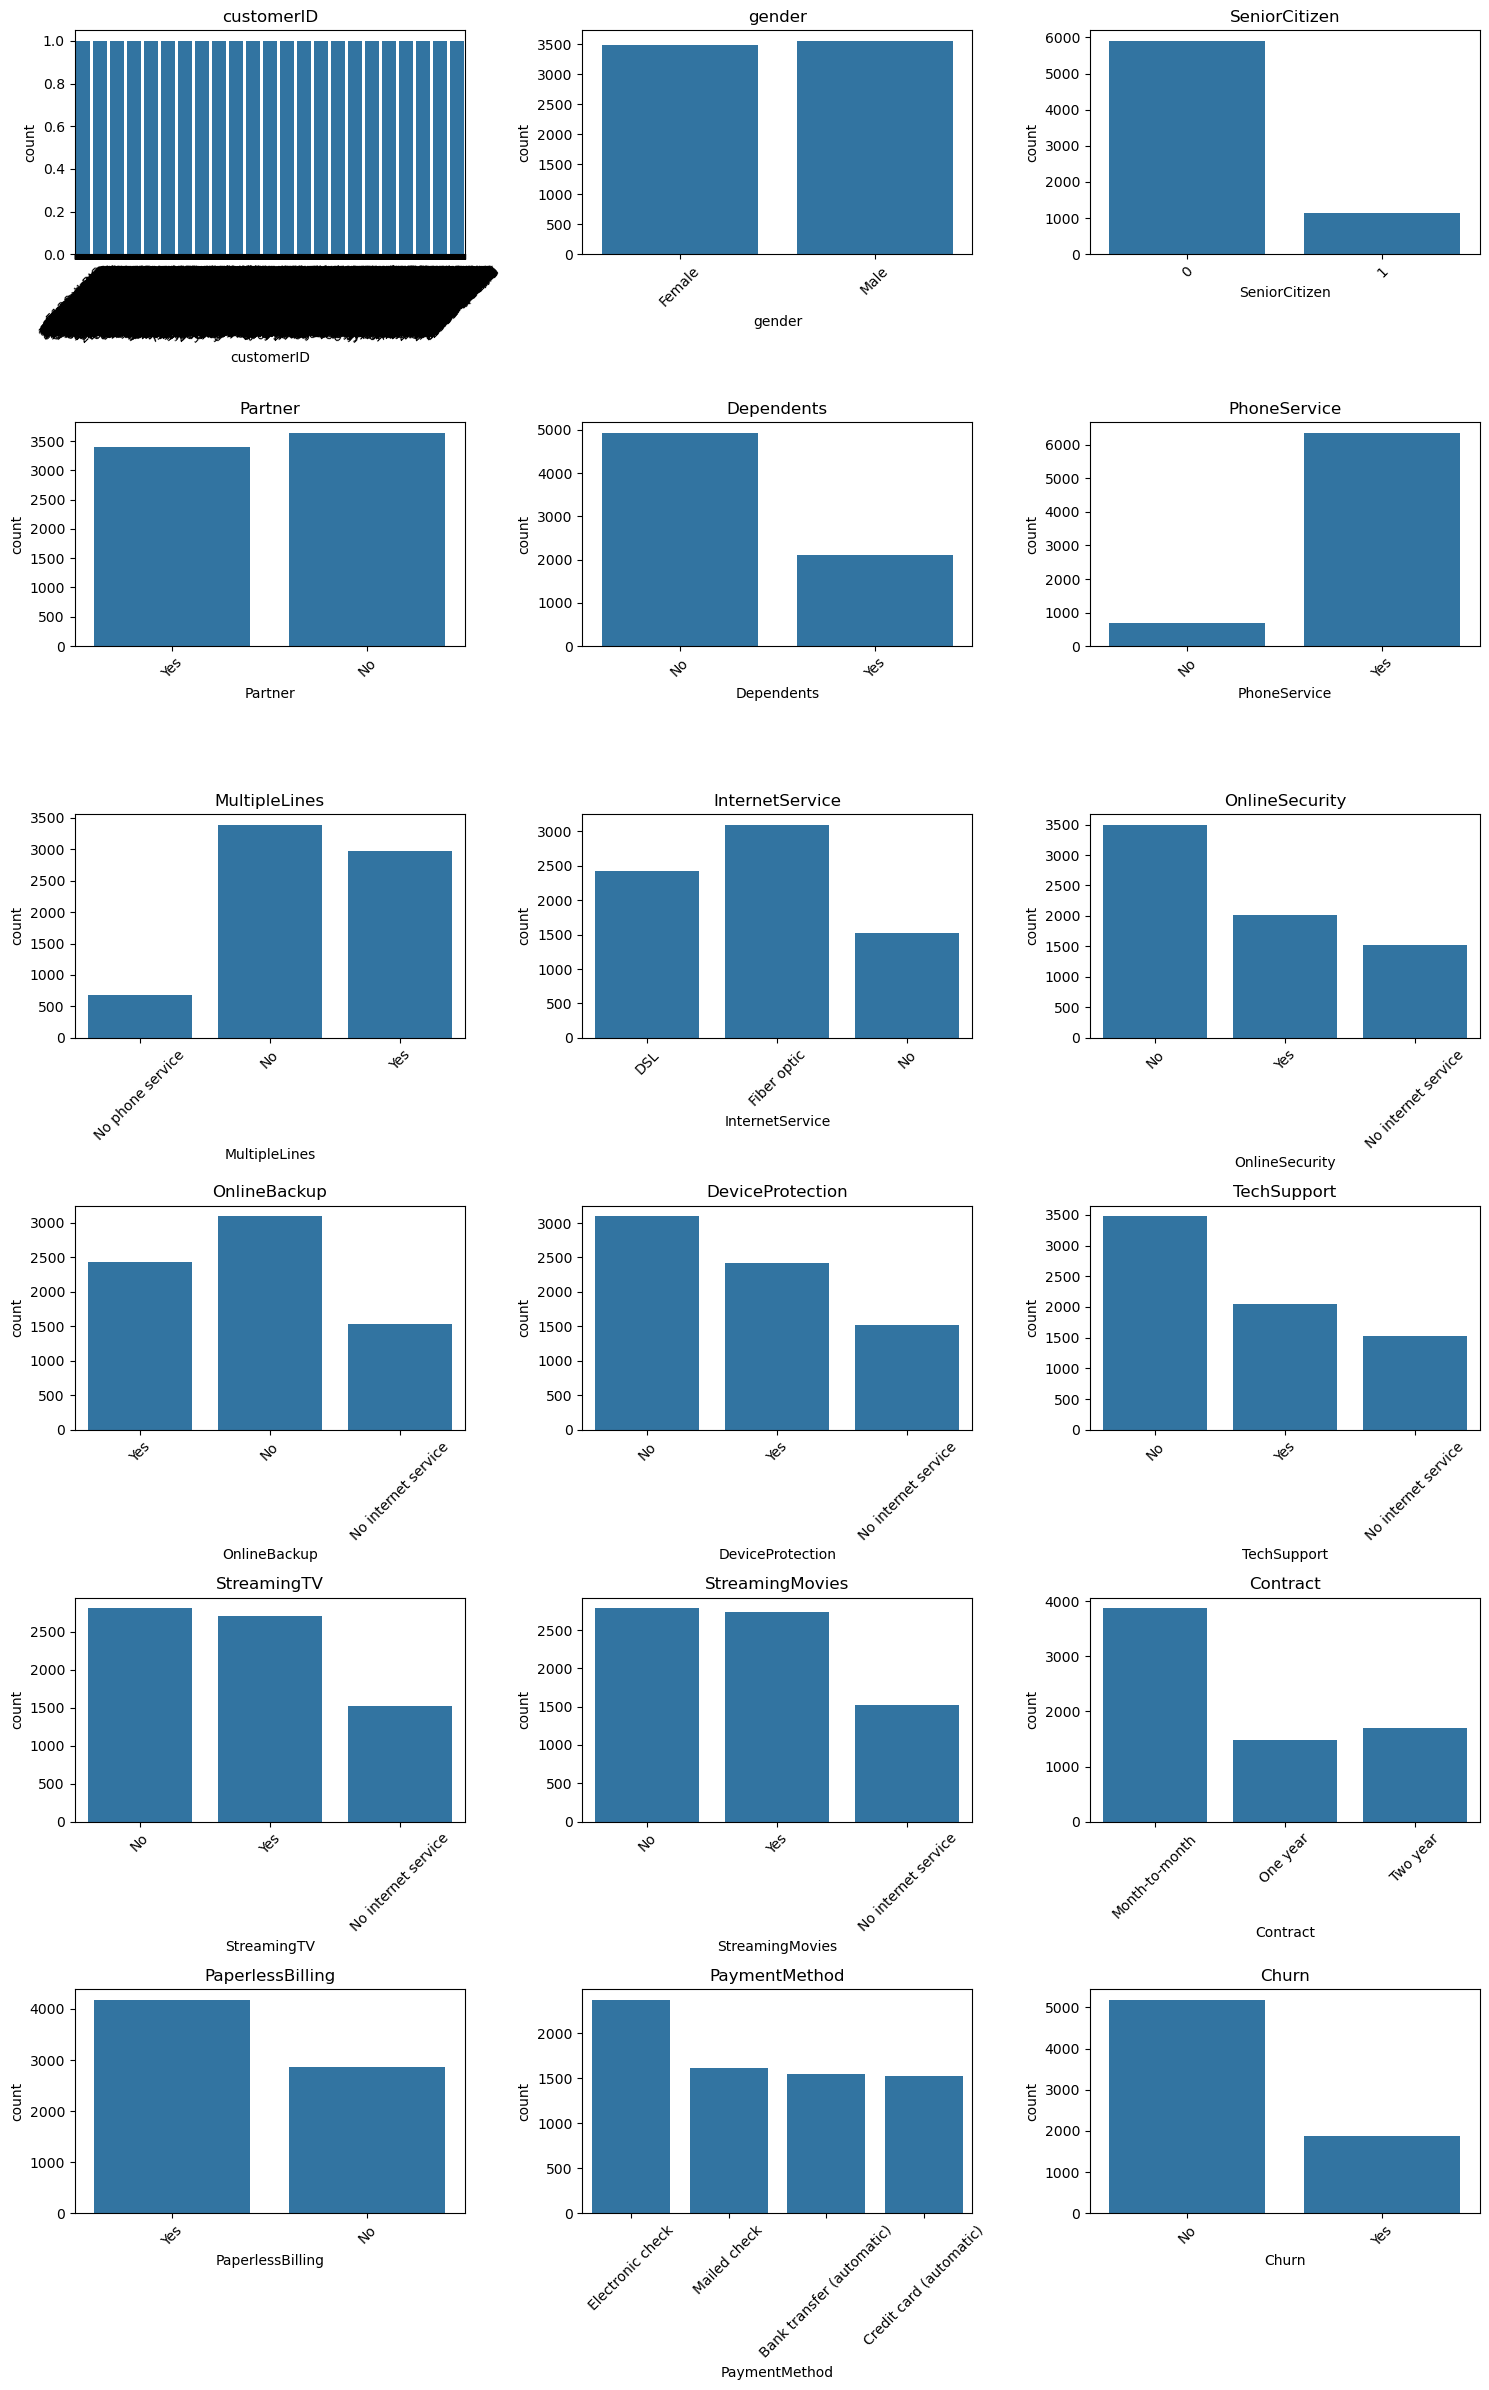

In [21]:

import math

cat_features = df.select_dtypes(include=['object']).columns.tolist()

n = len(cat_features)
rows = math.ceil(n / 3)
plt.figure(figsize=(15, rows * 4))

for i, feature in enumerate(cat_features):
    plt.subplot(rows, 3, i+1)
    sns.countplot(data=df, x=feature)
    plt.title(feature)
    plt.xticks(rotation=45)  #

plt.tight_layout()
plt.show()


## Bivariate analysis

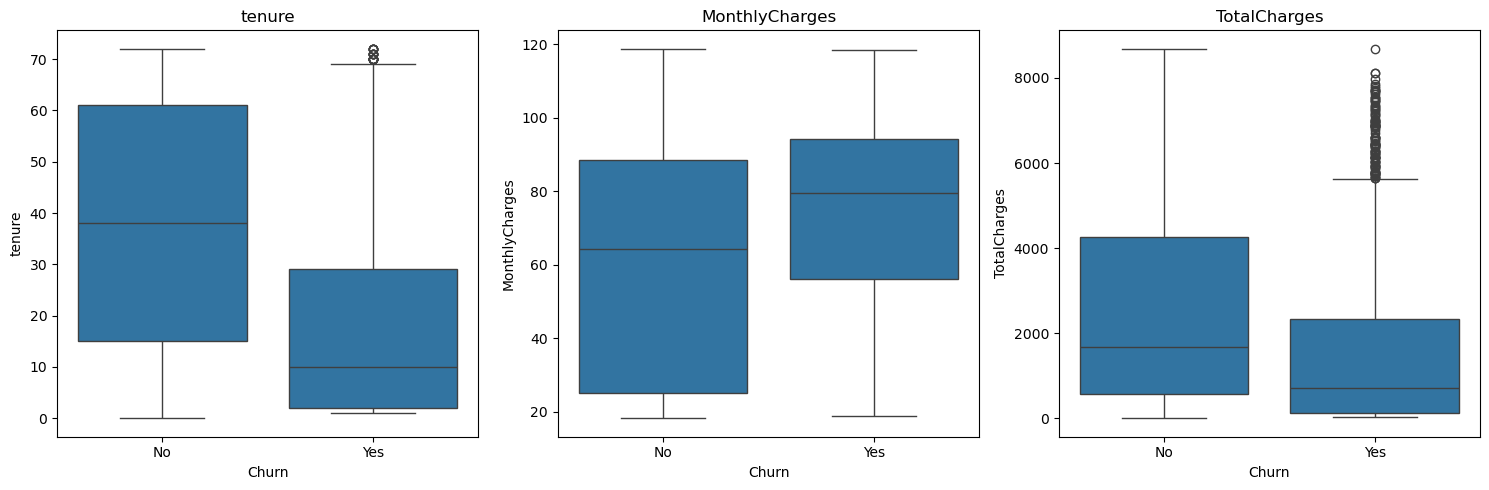

In [24]:

num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

n_cols = 3  
n_rows = (len(num_features) + n_cols - 1) // n_cols  
plt.figure(figsize=(15, n_rows * 5))

for i, col in enumerate(num_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df['Churn'], y=df[col])   
    plt.title(col)

plt.tight_layout()
plt.show()




- Customers who churned have significantly **lower tenure** , 
  new customers are far more likely to leave than long standing ones.
- Churners tend to have **higher monthly charges**, suggesting 
  price sensitivity is a key driver of cancellation.
- Churners show **lower total charges** overall, but this is 
  expected, customers who leave early naturally accumulate less 
  billing history rather than indicating they left because of low charges.

In [27]:
def plot_crosstabs(df, cat_cols, target):
    for col in cat_cols:
        tab= pd.crosstab(df[col], df[target], normalize='index')
        tab.plot(kind='bar', stacked=True, figsize=(7, 5))    # creating a stacked bar chart from the normalized crosstab
        plt.xlabel(col)
        plt.ylabel("proportion")
        plt.title(f"{col} vs {target}")
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title=target);    # adding a legend for the 'Churn' column

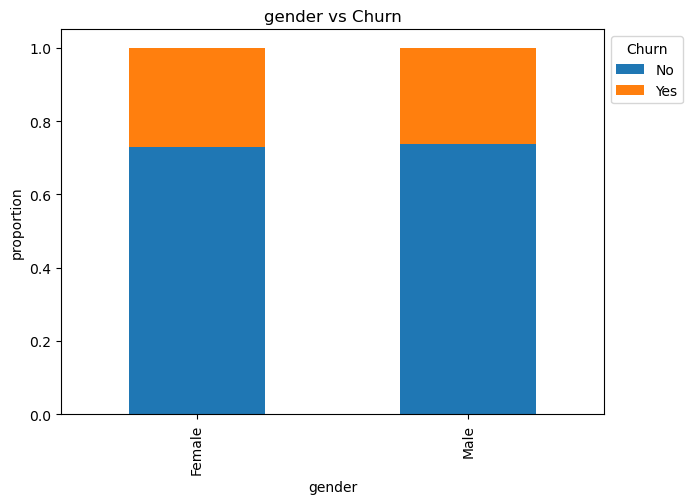

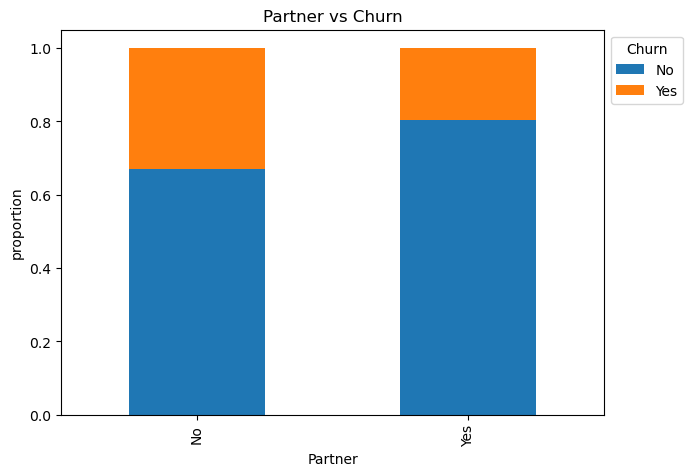

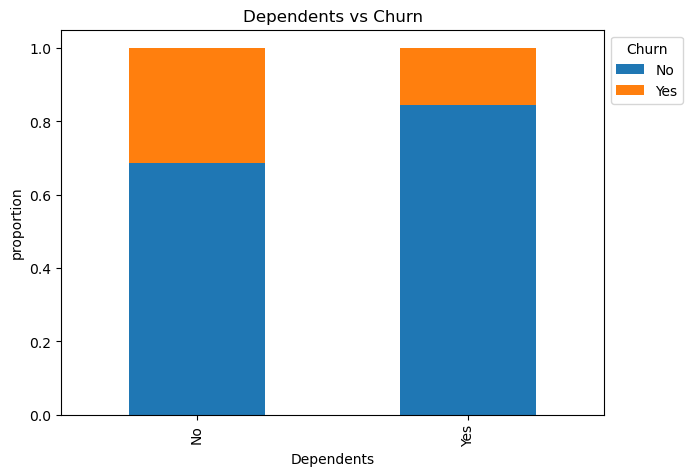

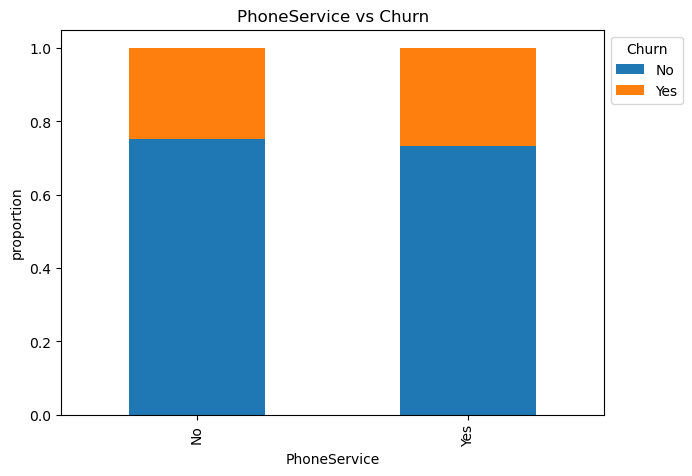

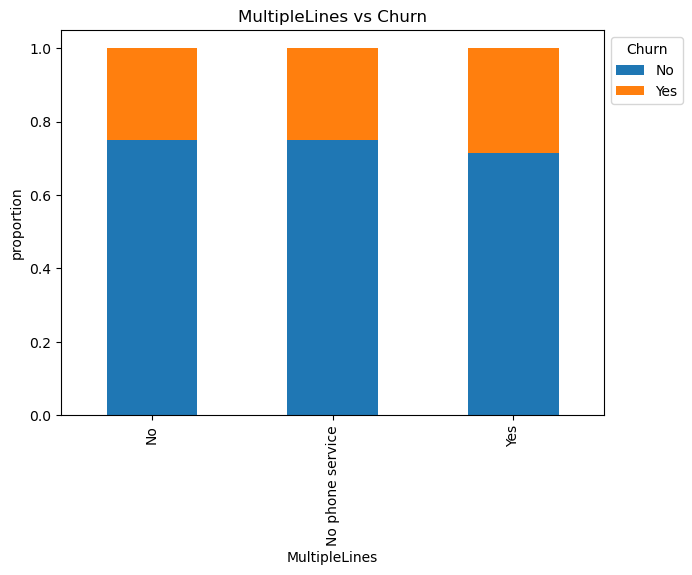

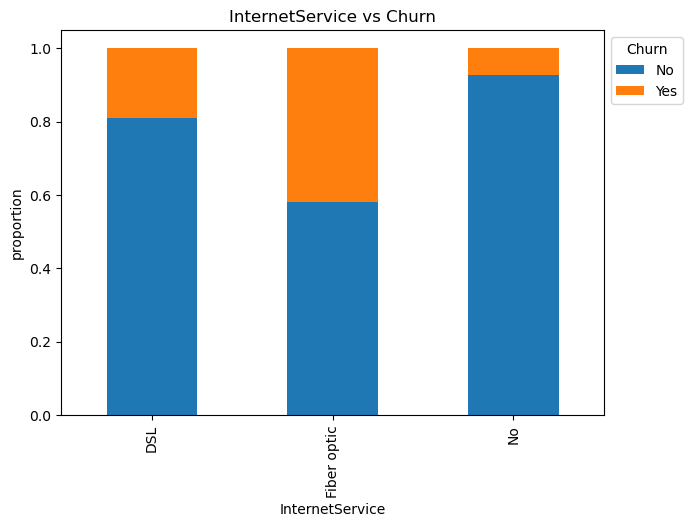

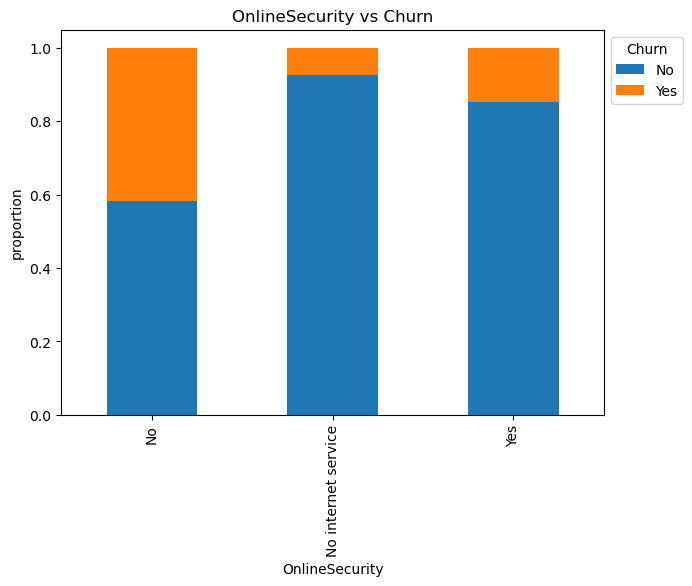

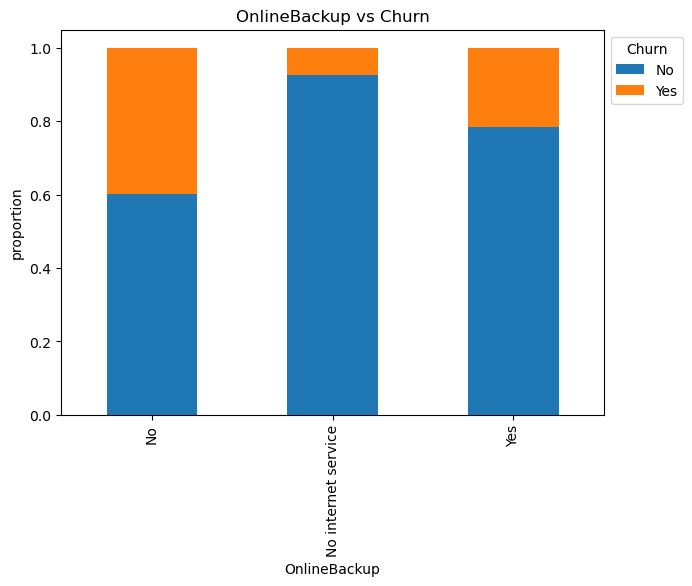

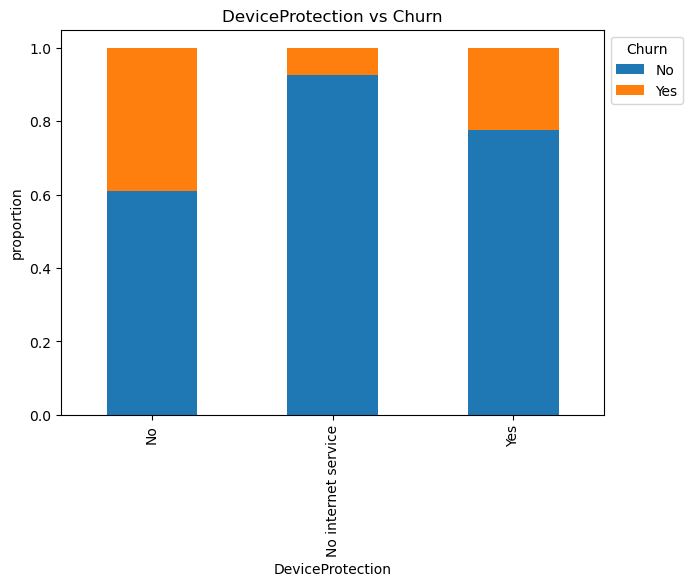

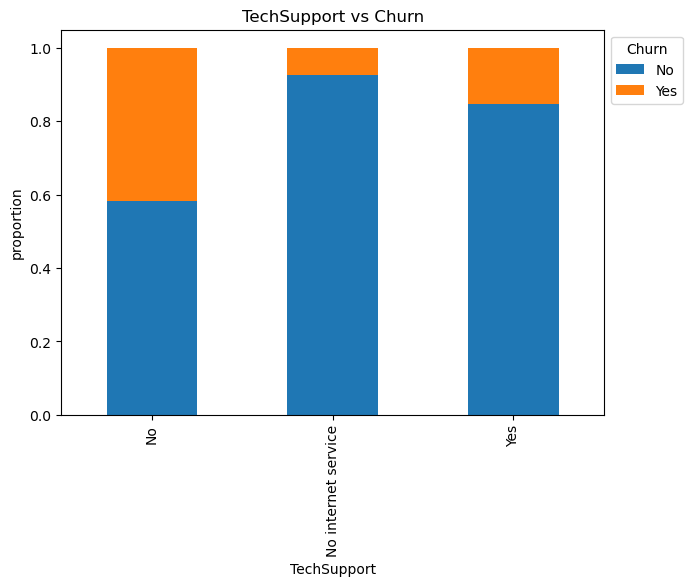

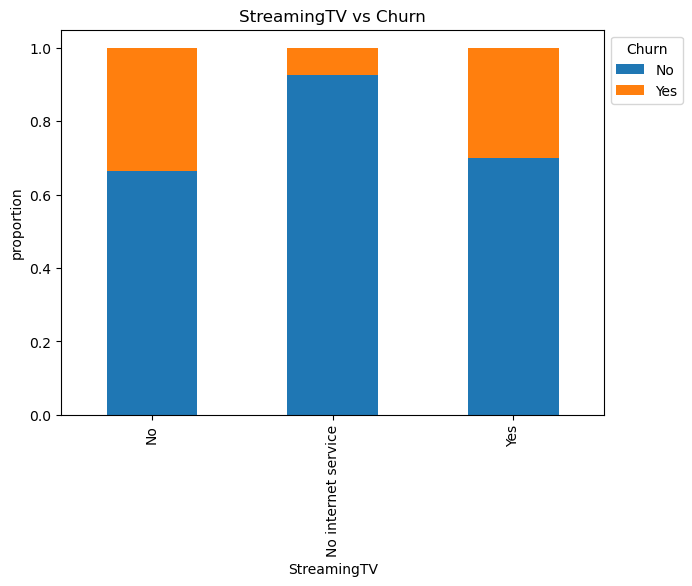

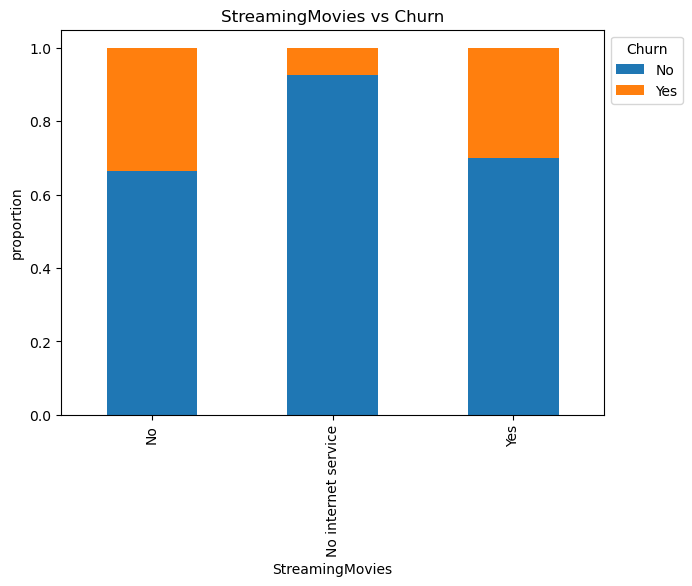

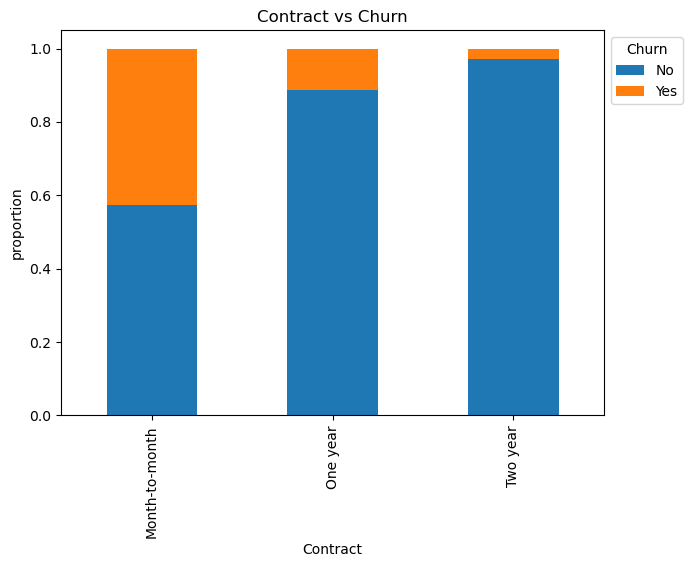

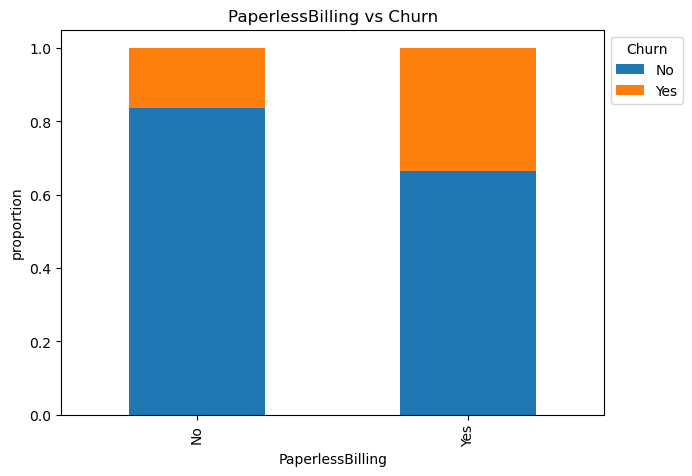

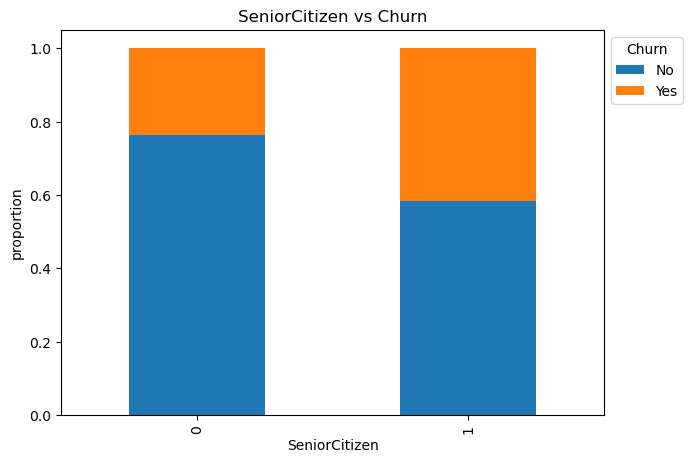

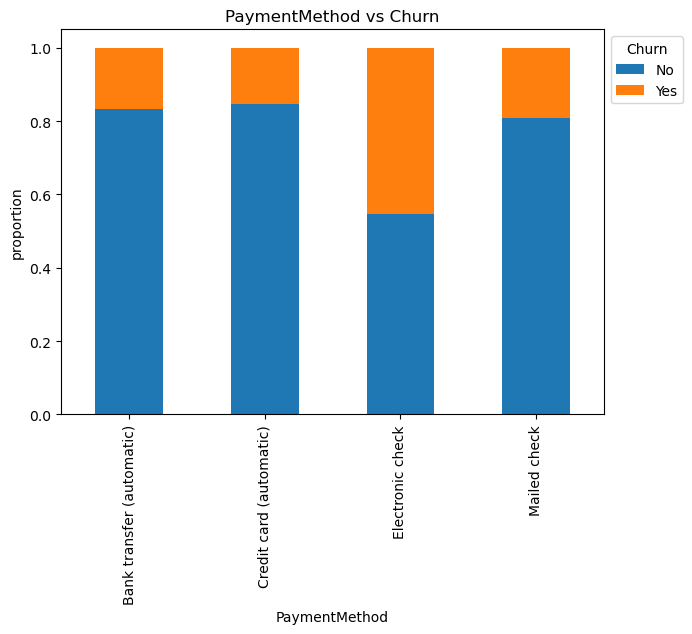

In [30]:
categorical_cols = ['gender','Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'SeniorCitizen', 'PaymentMethod']
plot_crosstabs(df, categorical_cols, 'Churn')



- **Gender** shows identical churn rates across male and female 
  customers, it carries no predictive signal and will be dropped.
- **Partner and Dependents** customers without partners or 
  dependents churn more, suggesting that family ties correlate 
  with stability and lower switching tendency.
- **PhoneService** churn rates are equal across subscribers 
  and non subscribers, confirming it adds no predictive value.
- **InternetService** fiber optic customers churn the most 
  despite (or possibly because of) paying a premium. DSL customers 
  are more stable and customers with no internet service churn the least.
- **Contract** month to month customers churn dramatically more 
  than one or two year contract holders. This is one of the strongest 
  signals in the dataset.
- **StreamingTV and StreamingMovies** nearly identical churn 
  patterns, confirming high correlation between these two features.

## feature engineering and selection

In [33]:

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Compute Cramér's V statistic for categorical-categorical association.
    x, y: array-like categorical variables (pandas Series recommended)
    Returns: float between 0 and 1
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(confusion_matrix, correction=False)
    n = confusion_matrix.sum().sum()
    if n == 0:
        return np.nan
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # bias correction: take min((r-1),(k-1))
    denom = n * min(r - 1, k - 1)
    if denom == 0:
        return 0.0
    return np.sqrt(phi2 / min(r - 1, k - 1))


In [34]:
def cramers_v_matrix(df, cat_cols):
    """
    Return a DataFrame matrix of Cramér's V values for columns in cat_cols.
    """
    mat = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
    for i in cat_cols:
        for j in cat_cols:
            if i == j:
                mat.loc[i, j] = 1.0
            else:
                mat.loc[i, j] = cramers_v(df[i], df[j])
    return mat


In [35]:
categorical_colss = ['gender','Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'SeniorCitizen', 'PaymentMethod', 'Churn']

In [36]:

print(cramers_v(df["StreamingMovies"], df["StreamingTV"]))
print(cramers_v_matrix(df, categorical_colss))


0.7710419124234426
                    gender   Partner  Dependents  PhoneService  MultipleLines  \
gender            1.000000  0.001808    0.010517      0.006488       0.009452   
Partner           0.001808  1.000000    0.452676      0.017706       0.143898   
Dependents        0.010517  0.452676    1.000000      0.001762       0.025094   
PhoneService      0.006488  0.017706    0.001762      1.000000       1.000000   
MultipleLines     0.009452  0.143898    0.025094      1.000000       1.000000   
InternetService   0.011320  0.000907    0.180267      0.452425       0.396726   
OnlineSecurity    0.017025  0.152010    0.194579      0.176272       0.229608   
OnlineBackup      0.013798  0.153337    0.162760      0.172818       0.245163   
DeviceProtection  0.006029  0.166568    0.157570      0.172317       0.246342   
TechSupport       0.009722  0.127642    0.182377      0.176977       0.230162   
StreamingTV       0.008844  0.137343    0.147082      0.180434       0.261791   
Streaming



Cramér's V was used to measure association between categorical 
features since standard correlation doesn't apply to categorical data.

- `StreamingMovies` and `StreamingTV` are strongly correlated 
  (V = 0.77) keeping both would add redundancy
- `PhoneService` and `MultipleLines` are perfectly correlated 
  (V = 1.0) `PhoneService` will be dropped in favour of `MultipleLines`
- `gender` shows near zero association with `Churn` confirms 
  the visual finding from the crosstab analysis
- `Contract` shows the strongest association with `Churn` among 
  all categorical features aligns with bivariate findings

In [38]:
df["num_addons"] = df[["OnlineSecurity", "OnlineBackup", "DeviceProtection",  "TechSupport",  "StreamingTV",  "StreamingMovies"]].apply(
    lambda x: sum(x=='Yes'), axis =1)

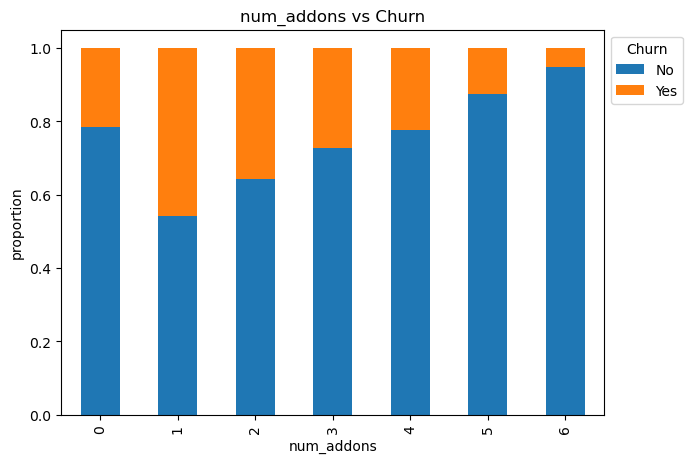

In [39]:
tab= pd.crosstab(df['num_addons'], df['Churn'], normalize='index')
tab.plot(kind='bar', stacked=True, figsize=(7, 5))    # creating a stacked bar chart from the normalized crosstab
plt.xlabel('num_addons')
plt.ylabel("proportion")
plt.title(f"{'num_addons'} vs {'Churn'}")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Churn');   

since many add on features were highly correlated i combined six of them into a single feature called "num_addons" to represent overall customer engagement. 

In [41]:
df.drop(columns=["OnlineSecurity", "OnlineBackup", "DeviceProtection",  "TechSupport",  "StreamingTV",  "StreamingMovies", "gender",
                "customerID", "PhoneService"], inplace=True)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,num_addons
0,0,Yes,No,1,No phone service,DSL,Month-to-month,Yes,Electronic check,29.85,29.85,No,1
1,0,No,No,34,No,DSL,One year,No,Mailed check,56.95,1889.50,No,2
2,0,No,No,2,No,DSL,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2
3,0,No,No,45,No phone service,DSL,One year,No,Bank transfer (automatic),42.30,1840.75,No,3
4,0,No,No,2,No,Fiber optic,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0


Several features were dropped to reduce redundancy and improve 
interpretability. The six add on features were combined into a single 
`num_addons` feature to capture overall customer engagement. `gender`, 
`customerID` and `PhoneService` were dropped, gender and PhoneService 
showed no predictive power for churn while customerID is a unique 
identifier with no modelling value.

In [44]:
df["churn_num"] = df["Churn"].map({
    'Yes': 1,
    "No": 0
})

#### Checking for multicorrelation

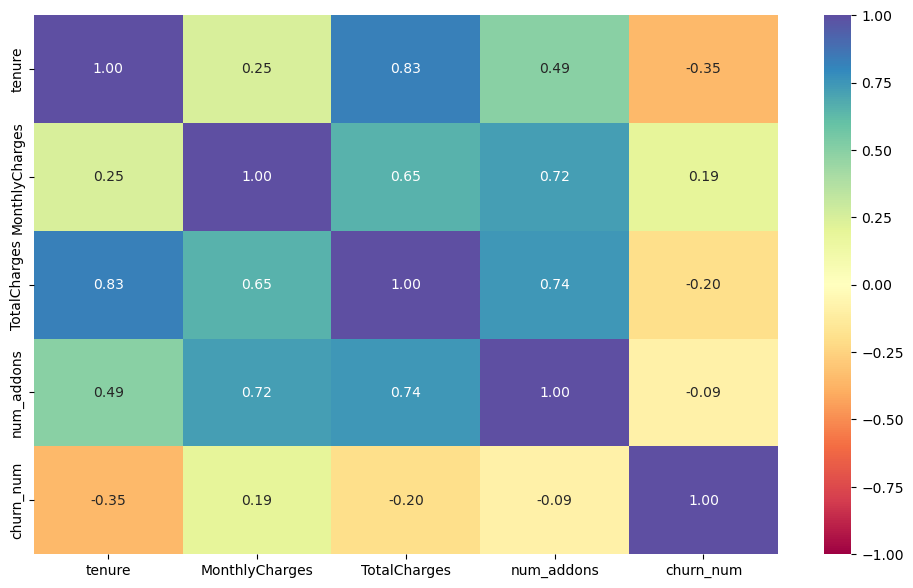

In [46]:
# defining the size of the plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 7))

# plotting the heatmap for correlation
sns.heatmap(
    df[df.select_dtypes(include=['number']).columns.tolist()].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral");

In [52]:
df.drop(columns=['TotalCharges', 'Churn'], inplace=True)

`TotalCharges` was dropped due to high multicollinearity with `tenure` 
(correlation: 0.83). Between the two, `tenure` was retained as it shows 
a stronger correlation with churn (-0.35 vs -0.20) and directly measures 
customer loyalty, a more meaningful predictor than cumulative billing 
which is largely a byproduct of how long someone has been subscribed.

In [56]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,num_addons,churn_num
0,0,Yes,No,1,No phone service,DSL,Month-to-month,Yes,Electronic check,29.85,1,0
1,0,No,No,34,No,DSL,One year,No,Mailed check,56.95,2,0
2,0,No,No,2,No,DSL,Month-to-month,Yes,Mailed check,53.85,2,1
3,0,No,No,45,No phone service,DSL,One year,No,Bank transfer (automatic),42.30,3,0
4,0,No,No,2,No,Fiber optic,Month-to-month,Yes,Electronic check,70.70,0,1


## Model building

In [58]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, precision_score, f1_score, recall_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from imblearn.pipeline import make_pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import confusion_matrix


In [60]:
X = df.drop(columns=["churn_num"])
y= df["churn_num"]

In [62]:

cat_columns = X.select_dtypes(include=["object"]).columns
num_columns = X.select_dtypes(include=["int64", "float64"]).columns

In [64]:
preprocessor = ColumnTransformer(
    transformers =[
        ('num', RobustScaler(), num_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop = 'first'), cat_columns)
    ]
)

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Build a baseline model

In [68]:
from sklearn.dummy import DummyClassifier

baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("dummy", DummyClassifier(strategy="stratified", random_state=42)) #built a baseline model
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}


baseline_scores = cross_validate(
    baseline,
    X_train,
    y_train,
    cv=5,
    scoring= scoring
)

for metric in scoring:
    print(f"Baseline {metric}: {baseline_scores[f'test_{metric}'].mean():.3f}")

Baseline accuracy: 0.595
Baseline precision: 0.239
Baseline recall: 0.241
Baseline f1: 0.240


In [70]:
ros = RandomOverSampler(random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "LightGBM": LGBMClassifier(objective="binary", random_state=42, verbose=-1),
    "XGBoost": XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42),
    "CatBoost": CatBoostClassifier(loss_function="Logloss", verbose=0, random_state=42)
}

scoring = {
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

cv_results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("oversample", ros),
        ("model", model)
    ])
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    cv_results[name] = {
        "Train Recall": scores["train_recall"].mean(),
        "Test Recall": scores["test_recall"].mean(),
        "Precision": scores["test_precision"].mean(),
        "F1": scores["test_f1"].mean()
    }

cv_df = pd.DataFrame(cv_results).T.sort_values("Test Recall", ascending=False)
print(cv_df)

                     Train Recall  Test Recall  Precision        F1
Gradient Boosting        0.832552     0.788771   0.509365  0.618675
Logistic Regression      0.794285     0.783434   0.501055  0.610866
SVM                      0.824869     0.781420   0.493111  0.604345
CatBoost                 0.910427     0.714562   0.528098  0.606745
LightGBM                 0.908254     0.709868   0.525320  0.602878
KNN                      0.895554     0.696524   0.450051  0.546700
XGBoost                  0.956551     0.643697   0.536900  0.584520
Random Forest            0.999331     0.566172   0.574778  0.569872


In [72]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('oversample', ros),
    ('model', LogisticRegression(max_iter=1000))
])

param_distributions = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

rs_cv = RandomizedSearchCV(
    estimator=pipeline_lr,
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs_cv.fit(X_train, y_train)

print("Best params:", rs_cv.best_params_)
print("Best CV Recall:", rs_cv.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': 0.01}
Best CV Recall: 0.8128338907469344


In [74]:
y_pred = rs_cv.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.70      0.80      1036
           1       0.50      0.85      0.63       373

    accuracy                           0.74      1409
   macro avg       0.72      0.77      0.71      1409
weighted avg       0.82      0.74      0.75      1409

[[723 313]
 [ 56 317]]


The model catches 85% of customers who will churn, giving the business the opportunity to intervene before they leave. Only 15% of churners are missed.

## Feature importance plot

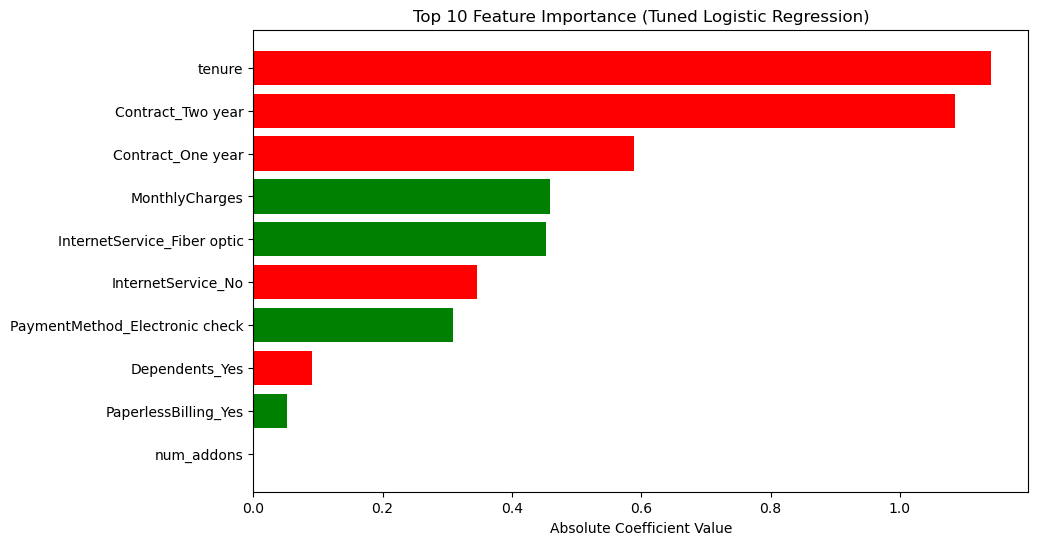

                           feature  coefficient
0                           tenure    -1.141485
11               Contract_Two year    -1.085182
10               Contract_One year    -0.589113
1                   MonthlyCharges     0.458504
8      InternetService_Fiber optic     0.452131
9               InternetService_No    -0.346493
14  PaymentMethod_Electronic check     0.308108
5                   Dependents_Yes    -0.091021
12            PaperlessBilling_Yes     0.052338
2                       num_addons     0.000000


In [81]:
fitted_preprocessor = rs_cv.best_estimator_.named_steps['preprocessor']

lr_model = rs_cv.best_estimator_.named_steps['model']
cat_ohe = fitted_preprocessor.named_transformers_['cat']
cat_feature_names = cat_ohe.get_feature_names_out(cat_columns)
feature_names = np.concatenate([num_columns, cat_feature_names])

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_model.coef_[0]
})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
top_features = coef_df.sort_values('abs_coefficient', ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in top_features['coefficient']]
plt.barh(top_features['feature'], top_features['abs_coefficient'], color=colors)
plt.gca().invert_yaxis()
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 10 Feature Importance (Tuned Logistic Regression)')
plt.show()

print(top_features[['feature', 'coefficient']])

## Feature Importance Analysis

`tenure` and `Contract_Two year` are the strongest retention factors — 
long standing customers on extended contracts are the least likely to churn. 
On the flip side, high `MonthlyCharges`, `Fiber optic` internet and 
`Electronic check` payments are the strongest churn drivers, suggesting 
that expensive, loosely committed customers are the highest risk segment.

Notably, `num_addons` had zero coefficient influence, indicating the 
engineered feature added no additional signal beyond what was already 
captured by the other encoded features.

## Model Results & Findings

After cross validating 8 models, Logistic Regression was selected as the 
final model. Despite being the simplest model in the comparison, it 
outperformed all ensemble models on Test Recall while showing the smallest 
gap between training and test scores confirming that the churn signal 
in this dataset is largely linear in nature.

**Model Performance:**
| Metric | Score |
|--------|-------|
| CV Recall (before tuning) | 0.799 |
| CV Recall (after tuning) | 0.813 |
| Test Recall | 0.850 |
| Test Precision | 0.500 |
| Test F1 | 0.630 |

**Business interpretation of results:**
Out of every 100 customers who will churn, the model successfully 
identifies 85 of them giving the business the opportunity to intervene 
before they cancel. Only 15 churners are missed. The trade-off is that 
some loyal customers are incorrectly flagged, but the cost of a false 
alarm (a unnecessary retention offer) is far lower than the cost of 
losing a customer entirely.

The tuned model significantly outperforms the baseline DummyClassifier 
which achieved only 0.24 recall confirming the model adds real 
predictive value beyond random guessing.

## Business Recommendations

Based on the model findings, the following retention strategies are recommended:

1. **Target new customers first** — tenure is the strongest churn predictor. 
   The first few months are the highest risk window. Onboarding incentives 
   and early engagement programs could significantly reduce early churn.

2. **Push long term contracts** — two year contract customers are the most 
   loyal segment. Offering discounts or perks for committing to longer 
   contracts is likely the single most effective retention strategy.

3. **Investigate fiber optic service quality** — fiber optic customers pay 
   a premium but churn at a higher rate. This suggests the service may not 
   be meeting expectations. A service quality review or targeted retention 
   offers for this segment is recommended.

4. **Incentivize automatic payments** — electronic check payers churn more. 
   Encouraging customers to switch to automatic bank transfers or credit card 
   payments could improve retention by increasing payment commitment.

5. **Prioritize high monthly charge customers** — these customers have the 
   most financial incentive to find cheaper alternatives. Loyalty rewards 
   or periodic plan reviews could reduce their churn risk.

In [83]:
import joblib
joblib.dump(rs_cv.best_estimator_, 'telecom_churn_pipeline.pkl') #save the full pipeline

['telecom_churn_pipeline.pkl']